# Flujo completo DXF -> discretizacion -> calibracion opcional

Procesa el DXF de ejemplo y muestra el diagnostico visual completo: fallas disponibles, columnas sin discretizar, discretizacion, perfil Vs, frecuencia natural y dos formas de resolver un estrato no identificado.

In [9]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src" / "dynaengine").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from dynaengine import (
    CalibrationSettings,
    export_dataframe,
    extract_columns_from_dxf,
    plot_column_discretized_detailed,
    plot_discretized_column,
    plot_dxf_extraction,
    plot_raw_column,
    process_dxf_folder,
)

DATA_DIR = ROOT / "examples" / "data"
SECTION_NAME = "section_01"
DXF_PATH = DATA_DIR / f"{SECTION_NAME}.dxf"
MATERIALS_PATH = DATA_DIR / f"{SECTION_NAME}_materials.json"
TARGET_FREQUENCY_HZ = 25
SMALL_AREA_SCALE = 0.01
UNKNOWN_MATERIAL_NAME = "Estrato no identificado 1"
REASSIGNED_MATERIAL_NAME = "Grava pobremente gradada"
RENAMED_UNKNOWN_MATERIAL_NAME = "Grava pobremente gradada caracterizada"
X_POSITIONS_BY_FAILURE = {
    f"failure_{index}": [250.0, 480.0] for index in range(1, 8)
}
FAILURE_TYPES = {name: "tipo_de_falla" for name in X_POSITIONS_BY_FAILURE}
X_POSITIONS = sorted(
    {x for positions in X_POSITIONS_BY_FAILURE.values() for x in positions}
)

materials = json.loads(MATERIALS_PATH.read_text(encoding="utf-8"))
unknown_material_template = next(
    material for material in materials if material["material_name"] == UNKNOWN_MATERIAL_NAME
)
unknown_material_properties = {
    key: value for key, value in unknown_material_template.items() if key != "material_name"
}
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print(f"Proyecto: {ROOT}")
print(f"DXF: {DXF_PATH.name}")
print(f"Materiales cargados: {len(materials)}")
print(f"Frecuencia objetivo de discretizacion: {TARGET_FREQUENCY_HZ} Hz")

Proyecto: C:\Users\joel.alarcon\Desktop\_code\prismo\external\DynaEngine
DXF: section_01.dxf
Materiales cargados: 6
Frecuencia objetivo de discretizacion: 25 Hz


### Fallas detectadas

,failure_id,failure_surface,failure_type,failure_height
0,1,failure_1,tipo_de_falla,14.38435
1,2,failure_2,tipo_de_falla,11.96292
2,3,failure_3,tipo_de_falla,10.23481
3,4,failure_4,tipo_de_falla,12.96041
4,5,failure_5,tipo_de_falla,18.25221
5,6,failure_6,tipo_de_falla,23.90455
6,7,failure_7,tipo_de_falla,16.90816


### Alertas de areas/materiales

,material_name,polygon_id,area_m2,area_ratio_to_total,notification_type,omitted_from_discretization,requires_material_resolution
0,Estrato no identificado 1,9,1792.27472,0.04343,[unidentified_material],False,True
1,Material dique,7,334.17383,0.00810,[small_area_omitted],True,False
2,Material de poza,6,132.32591,0.00321,[small_area_omitted],True,False
3,Grava arenosa,10,3.48914,0.00008,[small_area_omitted],True,False


### Columnas extraidas antes de discretizar

,column_name,failure_surface,x_position_m,failure_depth_m,freatic_depth_m,raw_layers,materials
0,section_01-failure_3-x250p0,failure_3,250.0,6.28905,33.54005,4,Grava arcillosa | Grava pobremente gradada | G...
1,section_01-failure_7-x480p0,failure_7,480.0,5.24264,19.57593,4,Grava arcillosa | Grava arenosa | Estrato no i...


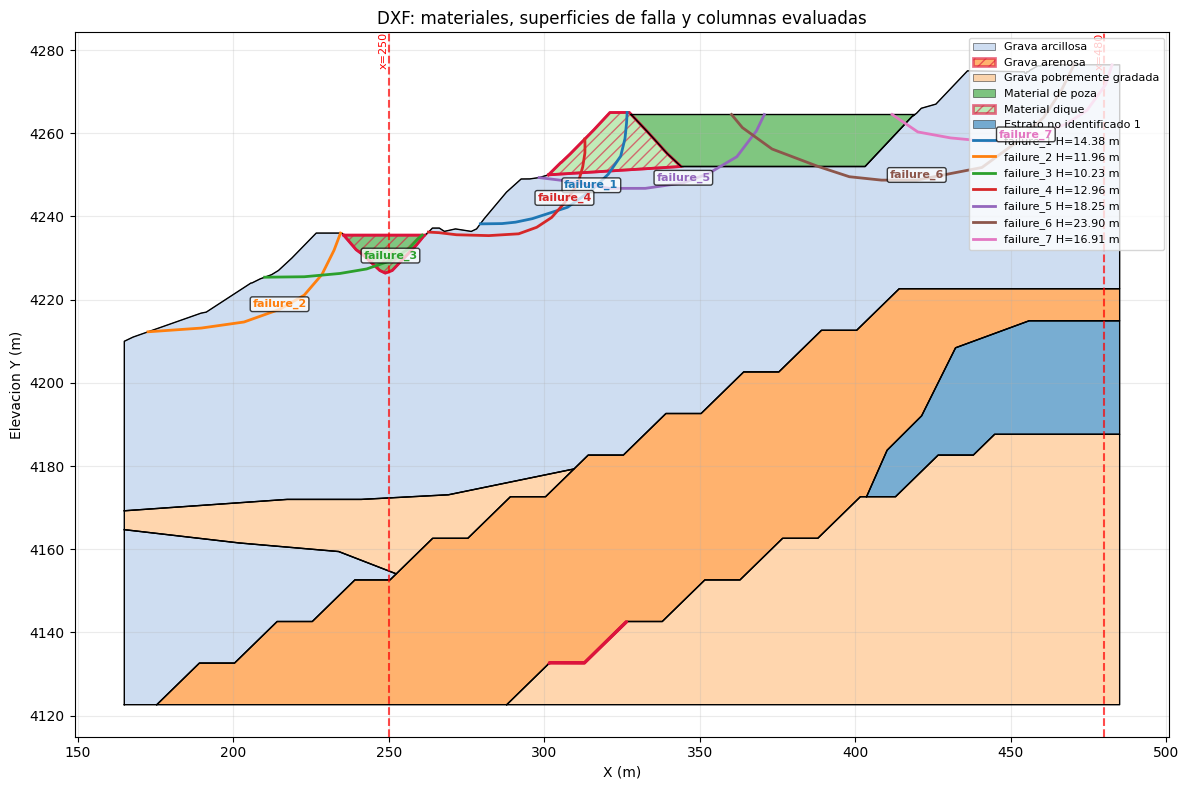

In [10]:
extraction = extract_columns_from_dxf(
    DXF_PATH,
    x_positions=X_POSITIONS_BY_FAILURE,
    failure_types=FAILURE_TYPES,
    small_area_scale=SMALL_AREA_SCALE,
)

failure_surfaces_df = (
    pd.DataFrame.from_dict(extraction.failure_surfaces, orient="index")
    .reset_index(drop=True)
    .sort_values("failure_id")
)
display(Markdown("### Fallas detectadas"))
display(failure_surfaces_df)

area_notifications_df = pd.DataFrame(extraction.area_notifications)
if not area_notifications_df.empty:
    display(Markdown("### Alertas de areas/materiales"))
    display(area_notifications_df[[
        "material_name",
        "polygon_id",
        "area_m2",
        "area_ratio_to_total",
        "notification_type",
        "omitted_from_discretization",
        "requires_material_resolution",
    ]])

extracted_columns_df = pd.DataFrame([
    {
        "column_name": name,
        "failure_surface": column["failure_surface"],
        "x_position_m": column["x_position"],
        "failure_depth_m": column["depth_failure_surface"],
        "freatic_depth_m": column["freatic"],
        "raw_layers": len(column["layers"]),
        "materials": " | ".join(layer["material"] for layer in column["layers"]),
    }
    for name, column in extraction.columns.items()
])
display(Markdown("### Columnas extraidas antes de discretizar"))
display(extracted_columns_df)

fig, ax = plot_dxf_extraction(
    extraction.clean_polygons,
    x_positions=X_POSITIONS,
    highlight_small_areas=True,
    small_area_scale=SMALL_AREA_SCALE,
    failure_polylines=extraction.failure_polylines,
    failure_surfaces=extraction.failure_surfaces,
    annotate_x_positions=True,
)
ax.set_title("DXF: materiales, superficies de falla y columnas evaluadas")
display(fig)
plt.close(fig)

### Caso 1: reasignar estrato no identificado a material existente

,case,column_name,raw_layers,discretized_segments,materials,min_frequency_hz
0,reasignado,section_01-failure_7-x480p0,4,48,Grava arcillosa | Grava arenosa | Grava pobrem...,25.000077


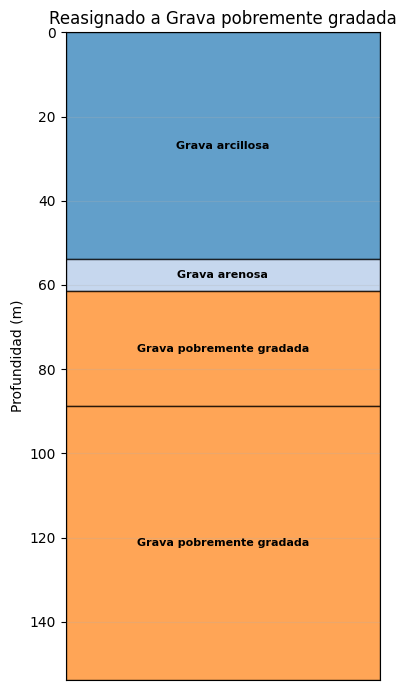

### Caso 2: caracterizar y renombrar estrato no identificado

,source_name,new_material_name,unit_weight_kn_m3,vs_depth,vs,dynamic_model
0,Estrato no identificado 1,Grava pobremente gradada caracterizada,19.0,"[0, 24, 30, 35]","[230, 300, 440, 550]",rojas_2019


,case,column_name,raw_layers,discretized_segments,materials,min_frequency_hz
0,caracterizado_renombrado,section_01-failure_7-x480p0,4,47,Grava arcillosa | Grava arenosa | Grava pobrem...,25.000077


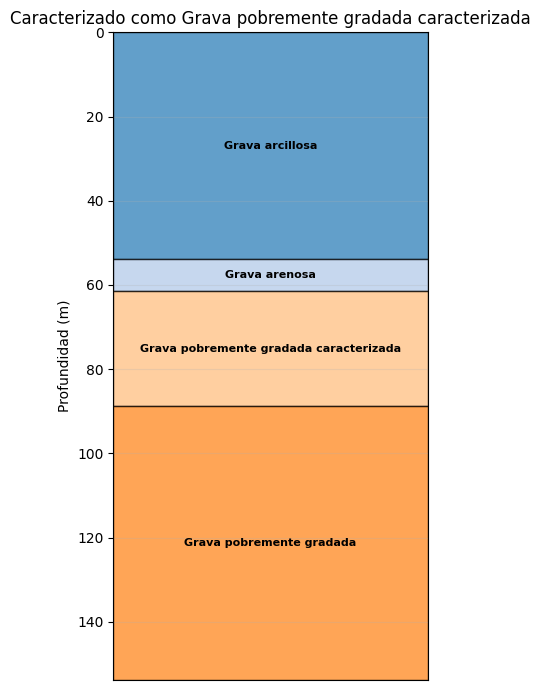

In [11]:
column_with_unknown = next(
    name
    for name, column in extraction.columns.items()
    if any(layer["material"] == UNKNOWN_MATERIAL_NAME for layer in column["layers"])
)


def material_sequence_frame(case_name, case_results):
    return pd.DataFrame([
        {
            "case": case_name,
            "column_name": name,
            "raw_layers": len(processed.raw),
            "discretized_segments": len(processed.discretized),
            "materials": " | ".join(processed.raw["material_name"]),
            "min_frequency_hz": processed.discretized["natural_frequency_hz"].min(),
        }
        for name, processed in case_results.items()
        if name == column_with_unknown
    ])

reassigned_results = process_dxf_folder(
    section_folder=DATA_DIR,
    x_positions_by_file={SECTION_NAME: X_POSITIONS_BY_FAILURE},
    materials=materials,
    target_frequency_hz=TARGET_FREQUENCY_HZ,
    calibrate=False,
    failure_types_by_file={SECTION_NAME: FAILURE_TYPES},
    material_aliases_by_file={SECTION_NAME: {UNKNOWN_MATERIAL_NAME: REASSIGNED_MATERIAL_NAME}},
    small_area_scale=SMALL_AREA_SCALE,
)

characterized_results = process_dxf_folder(
    section_folder=DATA_DIR,
    x_positions_by_file={SECTION_NAME: X_POSITIONS_BY_FAILURE},
    materials=materials,
    target_frequency_hz=TARGET_FREQUENCY_HZ,
    calibrate=False,
    failure_types_by_file={SECTION_NAME: FAILURE_TYPES},
    unidentified_material_actions_by_file={
        SECTION_NAME: {
            UNKNOWN_MATERIAL_NAME: {
                "action": "characterize",
                "name": RENAMED_UNKNOWN_MATERIAL_NAME,
                "properties": unknown_material_properties,
            }
        }
    },
    small_area_scale=SMALL_AREA_SCALE,
)

display(Markdown("### Caso 1: reasignar estrato no identificado a material existente"))
display(material_sequence_frame("reasignado", reassigned_results))
fig, ax = plot_raw_column(reassigned_results[column_with_unknown].raw, figsize=(4, 7))
ax.set_title(f"Reasignado a {REASSIGNED_MATERIAL_NAME}")
display(fig)
plt.close(fig)

display(Markdown("### Caso 2: caracterizar y renombrar estrato no identificado"))
display(pd.DataFrame([{
    "source_name": UNKNOWN_MATERIAL_NAME,
    "new_material_name": RENAMED_UNKNOWN_MATERIAL_NAME,
    "unit_weight_kn_m3": unknown_material_properties["unit_weight_kn_m3"],
    "vs_depth": unknown_material_properties["shear_velocity"]["depth"],
    "vs": unknown_material_properties["shear_velocity"]["vs"],
    "dynamic_model": unknown_material_properties["dynamic_model"]["model_type"],
}]))
display(material_sequence_frame("caracterizado_renombrado", characterized_results))
fig, ax = plot_raw_column(characterized_results[column_with_unknown].raw, figsize=(4, 7))
ax.set_title(f"Caracterizado como {RENAMED_UNKNOWN_MATERIAL_NAME}")
display(fig)
plt.close(fig)

In [12]:
results = process_dxf_folder(
    section_folder=DATA_DIR,
    x_positions_by_file={SECTION_NAME: X_POSITIONS_BY_FAILURE},
    materials=materials,
    target_frequency_hz=TARGET_FREQUENCY_HZ,
    calibrate=False,
    failure_types_by_file={SECTION_NAME: FAILURE_TYPES},
    small_area_scale=SMALL_AREA_SCALE,
)

print(f"Columnas procesadas: {len(results)}")
display(pd.DataFrame({"column_name": list(results)}))

Columnas procesadas: 2


,column_name
0,section_01-failure_3-x250p0
1,section_01-failure_7-x480p0


In [13]:
summary = []
for name, processed in results.items():
    summary.append({
        "column_name": name,
        "failure_surface": processed.raw["failure_surface_name"].iloc[0],
        "x_position_m": processed.raw["x_position_m"].iloc[0],
        "raw_layers": len(processed.raw),
        "discretized_segments": len(processed.discretized),
        "max_depth_m": processed.raw["bottom_m"].max(),
        "target_frequency_hz": TARGET_FREQUENCY_HZ,
        "min_frequency_hz": processed.discretized["natural_frequency_hz"].min(),
        "max_frequency_hz": processed.discretized["natural_frequency_hz"].max(),
        "min_vs_m_s": processed.discretized["shear_velocity_m_s"].min(),
        "max_vs_m_s": processed.discretized["shear_velocity_m_s"].max(),
    })
summary_df = pd.DataFrame(summary)
display(summary_df)

,column_name,failure_surface,x_position_m,raw_layers,discretized_segments,max_depth_m,target_frequency_hz,min_frequency_hz,max_frequency_hz,min_vs_m_s,max_vs_m_s
0,section_01-failure_3-x250p0,failure_3,250.0,4,42,112.87278,25,25.328390,75.985171,200.0,700.0
1,section_01-failure_7-x480p0,failure_7,480.0,4,47,153.82703,25,25.000077,75.240169,200.0,700.0


### section_01-failure_3-x250p0

**Columna sin discretizar**

,layer_id,material_name,top_m,bottom_m,thickness_m,shear_velocity_m_s,failure_surface_depth_m,passes_failure_surface
0,1,Grava arcillosa,0.00000,63.17022,63.17022,412.393911,6.28905,True
1,2,Grava pobremente gradada,63.17022,80.72175,17.55153,500.000000,6.28905,False
2,3,Grava arcillosa,80.72175,82.87298,2.15123,600.000000,6.28905,False
3,4,Grava arenosa,82.87298,112.87278,29.99980,700.000000,6.28905,False


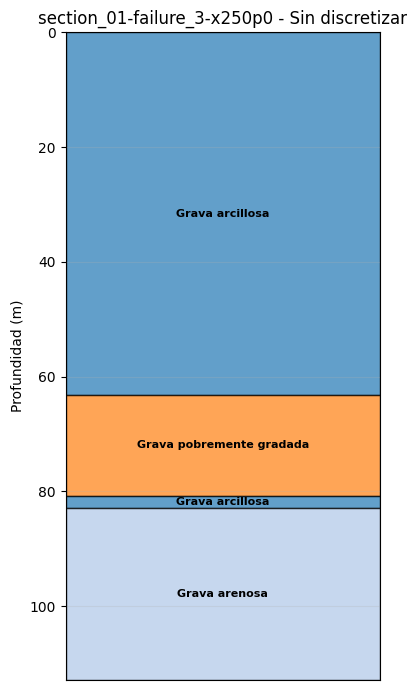

**Como se discretizo cada capa**

,source_layer_id,material_name,segments,top_m,bottom_m,min_segment_thickness_m,max_segment_thickness_m,min_frequency_hz,max_frequency_hz
0,1,Grava arcillosa,32,0.00000,63.17022,1.974069,1.974069,25.328390,75.985171
1,2,Grava pobremente gradada,4,63.17022,80.72175,4.387882,4.387882,28.487545,28.487545
2,3,Grava arcillosa,1,80.72175,82.87298,2.151230,2.151230,69.727551,69.727551
3,4,Grava arenosa,5,82.87298,112.87278,5.999960,5.999960,29.166861,29.166861


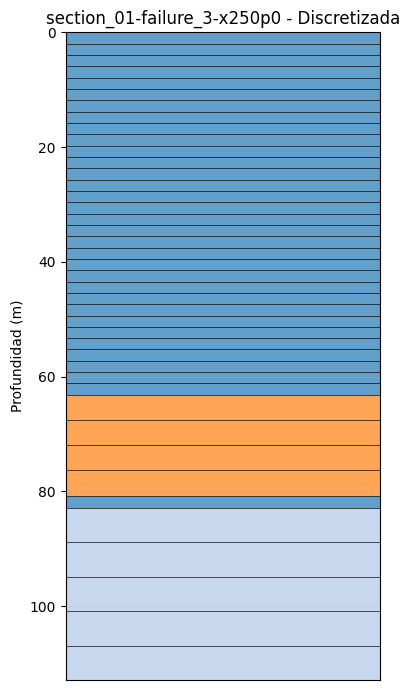

**Perfil final Vs y frecuencia natural por segmento**

,segment_id,source_layer_id,material_name,top_m,bottom_m,thickness_m,shear_velocity_m_s,natural_frequency_hz,passes_failure_surface
0,1,1,Grava arcillosa,0.000000,1.974069,1.974069,200.000000,25.328390,False
1,2,1,Grava arcillosa,1.974069,3.948139,1.974069,200.000000,25.328390,False
2,3,1,Grava arcillosa,3.948139,5.922208,1.974069,200.000000,25.328390,False
3,4,1,Grava arcillosa,5.922208,7.896278,1.974069,200.000000,25.328390,True
4,5,1,Grava arcillosa,7.896278,9.870347,1.974069,200.000000,25.328390,False
5,6,1,Grava arcillosa,9.870347,11.844416,1.974069,316.488849,40.080766,False
6,7,1,Grava arcillosa,11.844416,13.818486,1.974069,330.000000,41.791844,False
7,8,1,Grava arcillosa,13.818486,15.792555,1.974069,330.000000,41.791844,False
8,9,1,Grava arcillosa,15.792555,17.766624,1.974069,330.000000,41.791844,False
9,10,1,Grava arcillosa,17.766624,19.740694,1.974069,330.000000,41.791844,False


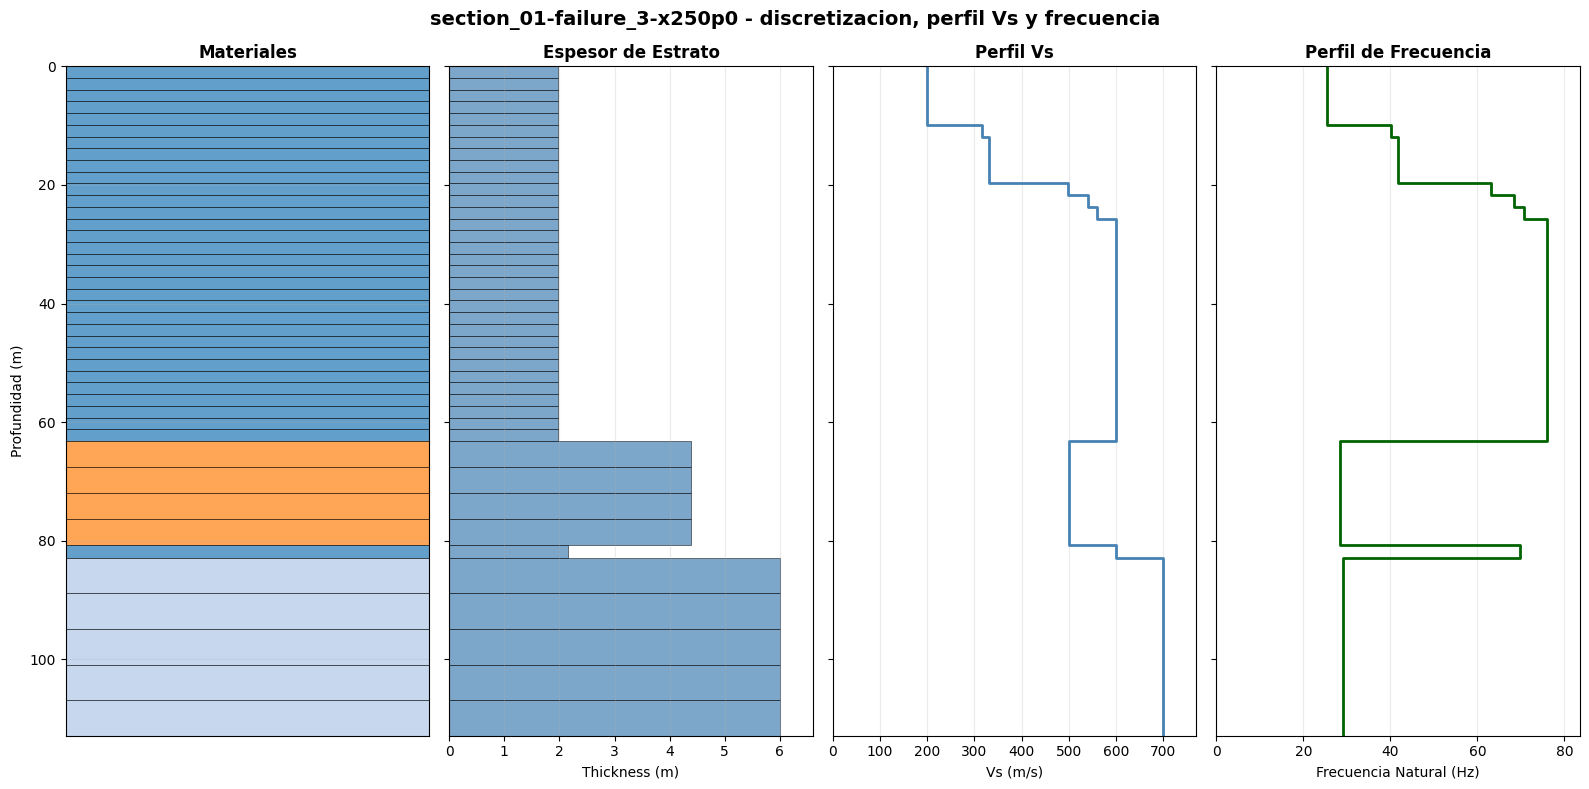

### section_01-failure_7-x480p0

**Columna sin discretizar**

,layer_id,material_name,top_m,bottom_m,thickness_m,shear_velocity_m_s,failure_surface_depth_m,passes_failure_surface
0,1,Grava arcillosa,0.00000,53.82763,53.82763,391.165464,5.24264,True
1,2,Grava arenosa,53.82763,61.53603,7.70840,700.000000,5.24264,False
2,3,Estrato no identificado 1,61.53603,88.82723,27.29120,550.000000,5.24264,False
3,4,Grava pobremente gradada,88.82723,153.82703,64.99980,500.000000,5.24264,False


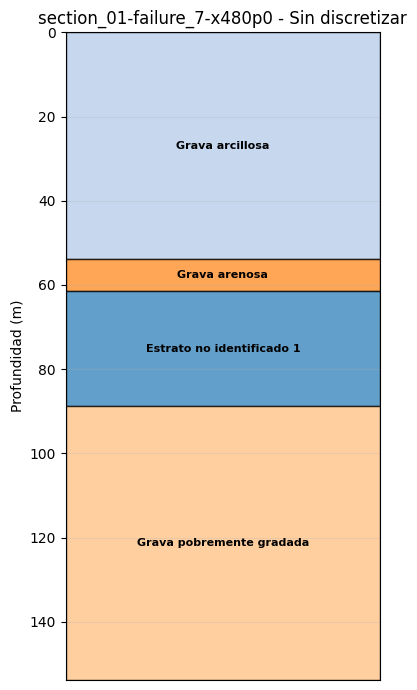

**Como se discretizo cada capa**

,source_layer_id,material_name,segments,top_m,bottom_m,min_segment_thickness_m,max_segment_thickness_m,min_frequency_hz,max_frequency_hz
0,1,Grava arcillosa,27,0.00000,53.82763,1.993616,1.993616,25.080056,75.240169
1,2,Grava arenosa,2,53.82763,61.53603,3.854200,3.854200,45.405013,45.405013
2,3,Estrato no identificado 1,5,61.53603,88.82723,5.458240,5.458240,25.191270,25.191270
3,4,Grava pobremente gradada,13,88.82723,153.82703,4.999985,4.999985,25.000077,25.000077


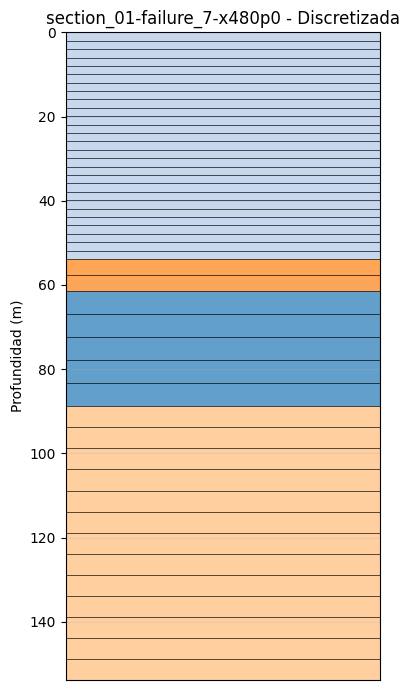

**Perfil final Vs y frecuencia natural por segmento**

,segment_id,source_layer_id,material_name,top_m,bottom_m,thickness_m,shear_velocity_m_s,natural_frequency_hz,passes_failure_surface
0,1,1,Grava arcillosa,0.000000,1.993616,1.993616,200.000000,25.080056,False
1,2,1,Grava arcillosa,1.993616,3.987232,1.993616,200.000000,25.080056,False
2,3,1,Grava arcillosa,3.987232,5.980848,1.993616,200.000000,25.080056,True
3,4,1,Grava arcillosa,5.980848,7.974464,1.993616,200.000000,25.080056,False
4,5,1,Grava arcillosa,7.974464,9.968080,1.993616,200.000000,25.080056,False
5,6,1,Grava arcillosa,9.968080,11.961696,1.993616,326.600953,40.955852,False
6,7,1,Grava arcillosa,11.961696,13.955311,1.993616,330.000000,41.382093,False
7,8,1,Grava arcillosa,13.955311,15.948927,1.993616,330.000000,41.382093,False
8,9,1,Grava arcillosa,15.948927,17.942543,1.993616,330.000000,41.382093,False
9,10,1,Grava arcillosa,17.942543,19.936159,1.993616,330.000000,41.382093,False


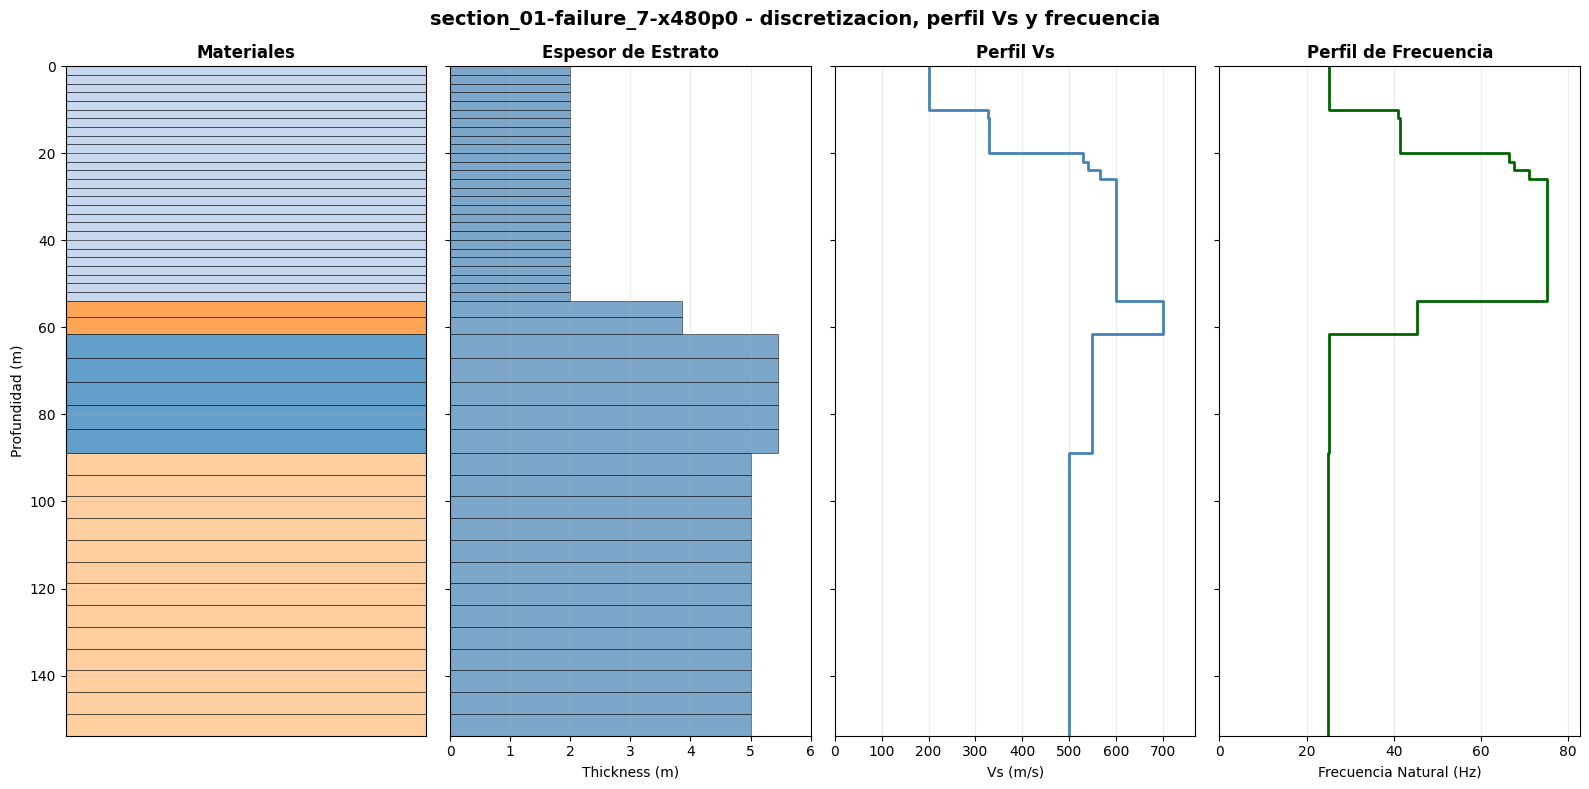

In [14]:
RAW_COLUMNS = [
    "layer_id",
    "material_name",
    "top_m",
    "bottom_m",
    "thickness_m",
    "shear_velocity_m_s",
    "failure_surface_depth_m",
    "passes_failure_surface",
]
PROFILE_COLUMNS = [
    "segment_id",
    "source_layer_id",
    "material_name",
    "top_m",
    "bottom_m",
    "thickness_m",
    "shear_velocity_m_s",
    "natural_frequency_hz",
    "passes_failure_surface",
]


def discretization_summary(discretized):
    return (
        discretized
        .groupby(["source_layer_id", "material_name"], as_index=False)
        .agg(
            segments=("segment_id", "count"),
            top_m=("top_m", "min"),
            bottom_m=("bottom_m", "max"),
            min_segment_thickness_m=("thickness_m", "min"),
            max_segment_thickness_m=("thickness_m", "max"),
            min_frequency_hz=("natural_frequency_hz", "min"),
            max_frequency_hz=("natural_frequency_hz", "max"),
        )
    )


def show_column_diagnostics(name, processed):
    display(Markdown(f"### {name}"))

    display(Markdown("**Columna sin discretizar**"))
    display(processed.raw[RAW_COLUMNS])
    fig, ax = plot_raw_column(processed.raw, figsize=(4, 7))
    ax.set_title(f"{name} - Sin discretizar")
    display(fig)
    plt.close(fig)

    display(Markdown("**Como se discretizo cada capa**"))
    display(discretization_summary(processed.discretized))
    fig, ax = plot_discretized_column(processed.discretized, figsize=(4, 7))
    ax.set_title(f"{name} - Discretizada")
    display(fig)
    plt.close(fig)

    display(Markdown("**Perfil final Vs y frecuencia natural por segmento**"))
    display(processed.discretized[PROFILE_COLUMNS])
    fig, axes = plot_column_discretized_detailed(processed.discretized, figsize=(16, 8))
    fig.suptitle(f"{name} - discretizacion, perfil Vs y frecuencia", fontsize=14, weight="bold")
    fig.tight_layout()
    display(fig)
    plt.close(fig)


for name, processed in results.items():
    show_column_diagnostics(name, processed)

In [15]:
output_dir = ROOT / "examples" / "output"
output_dir.mkdir(parents=True, exist_ok=True)

for name, processed in results.items():
    export_dataframe(processed.raw, output_dir / f"{name}_raw.csv")
    export_dataframe(processed.discretized, output_dir / f"{name}_discretized.csv")
export_dataframe(summary_df, output_dir / "columns_summary.csv")
print(output_dir)

C:\Users\joel.alarcon\Desktop\_code\prismo\external\DynaEngine\examples\output


In [16]:
# Calibracion de todas las columnas correctas con una discretizacion ligera para ejemplo.
# Para produccion, sube target_frequency_hz y/o scipy_starts/scipy_maxiter.
settings = CalibrationSettings(
    optimizer="scipy",
    scipy_starts=1,
    scipy_maxiter=8,
    random_state=1,
)

calibrated_results = process_dxf_folder(
    section_folder=DATA_DIR,
    x_positions_by_file={SECTION_NAME: X_POSITIONS_BY_FAILURE},
    materials=materials,
    target_frequency_hz=2,
    calibrate=True,
    calibration_settings=settings,
    failure_types_by_file={SECTION_NAME: FAILURE_TYPES},
    small_area_scale=SMALL_AREA_SCALE,
)

calibrated_values = pd.concat(
    [processed.calibrated.assign(correct_column=name) for name, processed in calibrated_results.items()],
    ignore_index=True,
)
display(calibrated_values[[
    "correct_column",
    "segment_id",
    "source_layer_id",
    "x_position_m",
    "failure_surface_id",
    "failure_surface_name",
    "material_name",
    "top_m",
    "bottom_m",
    "theta_1",
    "theta_2",
    "theta_3",
    "theta_4",
    "theta_5",
    "P1",
    "P2",
    "P3",
    "dmin",
    "gqh_score",
    "mrdf_score",
]])

,correct_column,segment_id,source_layer_id,x_position_m,failure_surface_id,failure_surface_name,material_name,top_m,bottom_m,theta_1,theta_2,theta_3,theta_4,theta_5,P1,P2,P3,dmin,gqh_score,mrdf_score
0,section_01-failure_3-x250p0,1,1,250.0,3,failure_3,Grava arcillosa,0.000000,31.585110,-1.172526,0.065445,7.440467,1.0,4.328080e-01,0.578368,0.391843,3.451044,0.957962,-0.014039,-3.832506e-02
1,section_01-failure_3-x250p0,2,1,250.0,3,failure_3,Grava arcillosa,31.585110,63.170220,0.712551,-0.463178,0.010000,1.0,1.345487e-09,0.387030,0.207029,2.869494,0.872754,-0.039947,-6.828932e-02
2,section_01-failure_3-x250p0,3,2,250.0,3,failure_3,Grava pobremente gradada,63.170220,80.721750,1.453080,-1.010625,0.010000,1.0,1.741039e-06,0.233462,0.050000,30.000000,0.791098,-0.030822,-3.987978e-01
3,section_01-failure_3-x250p0,4,3,250.0,3,failure_3,Grava arcillosa,80.721750,82.872980,0.429821,-0.423716,0.010032,1.0,5.407279e-10,0.553365,0.369294,1.882501,0.772378,-0.033048,-3.875245e-02
4,section_01-failure_3-x250p0,5,4,250.0,3,failure_3,Grava arenosa,82.872980,112.872780,0.910146,-0.442800,0.010000,1.0,7.180502e-09,0.999934,0.194833,0.500036,7.082448,-0.039846,-7.961473e-01
5,section_01-failure_7-x480p0,1,1,480.0,7,failure_7,Grava arcillosa,0.000000,26.913815,-0.772089,-1.670321,3.016279,1.0,3.511285e-01,0.576480,0.346828,2.638987,0.923574,-0.012789,-3.404013e-01
6,section_01-failure_7-x480p0,2,1,480.0,7,failure_7,Grava arcillosa,26.913815,53.827630,0.930782,-0.444093,0.010000,1.0,7.423405e-09,0.256477,0.203905,27.889526,1.153274,-0.051457,-4.510494e-01
7,section_01-failure_7-x480p0,3,2,480.0,7,failure_7,Grava arenosa,53.827630,61.536030,1.364179,-0.519896,4.948154,1.0,2.361019e-01,0.999934,0.110032,15.249431,7.983739,-0.092798,-8.805020e-01
8,section_01-failure_7-x480p0,4,3,480.0,7,failure_7,Estrato no identificado 1,61.536030,88.827230,-0.778881,-0.351850,0.010044,1.0,8.285113e-07,0.590212,0.201036,15.833698,0.696816,-0.008754,-3.559806e-02
9,section_01-failure_7-x480p0,5,4,480.0,7,failure_7,Grava pobremente gradada,88.827230,121.327130,1.026600,-0.470824,0.010000,1.0,7.053187e-06,0.500000,0.525000,15.250000,5.000000,-0.014568,-1.000000e+12
